# MATH 4340 / COSC 4340: Numerical Methods for Differential Equations
# Notebook 14: Finite Difference Methods for PDEs

### Professor: Dane Taylor
### Date: Spring 2024


In [17]:
%pylab inline
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## 1. Example 1: Finite Difference Method for Heat Equation


In [18]:
D = 0.1 # diffusion coefficient

n = 20 # number of grid points
a,b = 0.,1.
xi = linspace(a,b,n+1) # grid points
h = 1/n # grid spacing

N = 2000 # number time steps
t0,T = 0.,5.
tj = linspace(t0,T,N+1) # time points
k = (T-t0)/N # timestep size

# initital condition
def normal_curve(x ,mean=0.5,sd=0.1):
    prob_density =  exp(-0.5*((x-mean)/sd)**2)
    return prob_density
u0 = normal_curve(xi)

l,r = 0,0.5 # fixed temperature at left and right boundaries
u0[0],u0[-1] = l,r

In [19]:
def rhs(u, h=.1, D=1):
    n = len(u)-1 # number of grid points
    
    # finite difference approx to 2nd derivative w.r.t. variable x
    f = zeros(n+1)    
    f[1:-1] = D/h**2 * (u[2:]  - 2*u[1:-1] + u[:-2]) 
        
    return f

In [20]:
# iterate time steps
uu = np.empty((N+1, n+1))
uu[0] = u0.copy()

for j in range(N):
    uu[j+1] = uu[j] + k * rhs(uu[j], h, D)
    uu[j+1,0] = l
    uu[j+1,-1] = r

In [21]:
plot_js = [10,100,500,1000,1900] # select a few times to plot
tj[plot_js]

array([0.025, 0.25 , 1.25 , 2.5  , 4.75 ])

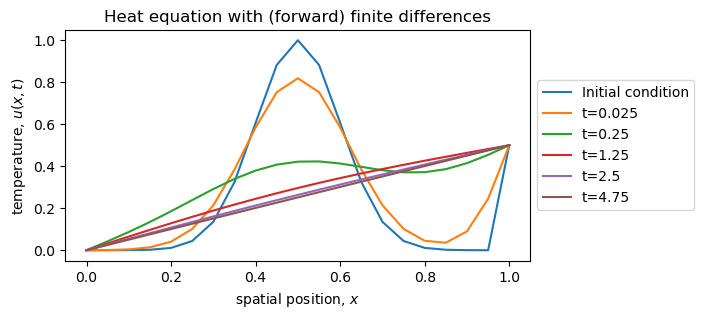

In [26]:
# plot the solution at several times
fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(xi, uu[0], label='Initial condition')
for j in plot_js:
    ax.plot(xi, uu[j], label='t='+str(tj[j]))

ax.set_xlabel('spatial position, $x$')
ax.set_ylabel('temperature, $u(x,t)$')
ax.set_title('Heat equation with (forward) finite differences')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5));

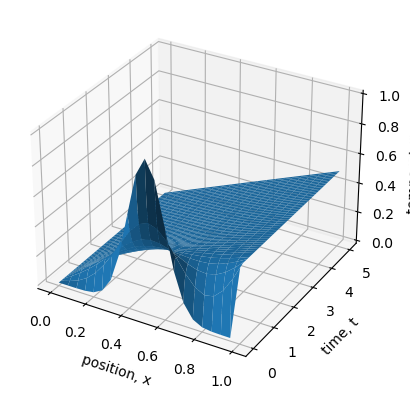

In [24]:
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111, projection='3d')
xx, tt = np.meshgrid(xi, tj)
ax.plot_surface(xx, tt, uu)

ax.set_xlabel('position, x')
ax.set_ylabel('time, t')
ax.set_zlabel('temperature, u')
plt.tight_layout();

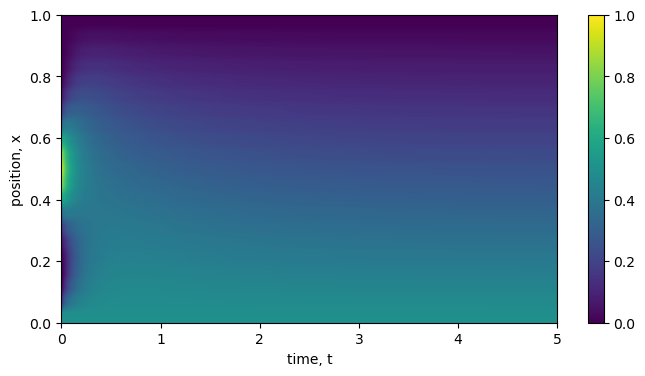

In [35]:
fig = plt.figure(figsize=(8,4))
imshow(uu.T,aspect='auto',extent=[t0,T,a,b])
xlabel('time, t')
ylabel('position, x')
colorbar()

## 2. Forward finite different method with matrix implementation

In [36]:
sigma = k*D/h**2
print('sigma = ',sigma)
A = (1-2*sigma)*eye(n-1) + diag(sigma*ones(n-2),-1) + diag(sigma*ones(n-2),1)
A = sparse.csr_matrix(A)

sigma =  0.09999999999999998


In [27]:
# iterate time steps
uu = np.empty((N+1, n+1))
uu[0] = u0.copy()

uu[:,0] = l
uu[:,-1] = r


s = zeros(n-1)
s[0] = sigma*l
s[-1] = sigma*r

for j in range(N):
    uu[j+1,1:-1] = A@uu[j,1:-1] + s

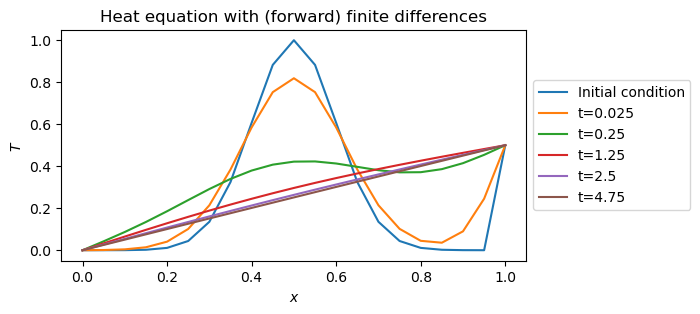

In [38]:
# plot the solution at several times
fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(xi, uu[0], label='Initial condition')
for j in plot_js:
    ax.plot(xi, uu[j], label='t='+str(tj[j]))

ax.set_xlabel('$x$')
ax.set_ylabel('$T$')
ax.set_title('Heat equation with (forward) finite differences')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5));

## 3. Von Neumann stability of method
* Let's decrease the number of time steps

In [39]:
D = 0.1 # diffusion coefficient
 
N = 385 # number time steps
t0,T = 0.,5.
tj = linspace(t0,T,N+1) # time points
k = (T-t0)/N # timestep size

sigma = k*D/h**2
A = (1-2*sigma)*eye(n-1) + diag(sigma*ones(n-2),-1) + diag(sigma*ones(n-2),1)
A = sparse.csr_matrix(A)

s = zeros(n-1)
s[0] = l
s[-1] = r

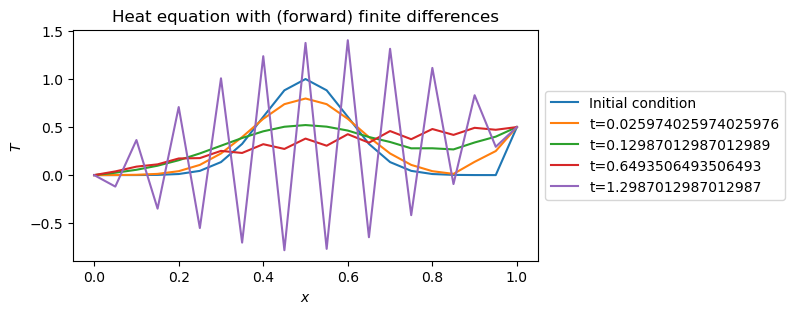

In [40]:
# iterate time steps
uu = np.empty((N+1, n+1))
uu[0] = u0.copy()

for j in range(N):
    uu[j+1,1:-1] = A@uu[j,1:-1] + sigma*s
    uu[j+1,0] = l
    uu[j+1,-1] = r
    
# plot the solution at several times
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(xi, uu[0], label='Initial condition')

plot_js = [2,10,50,100] # select a few times to plot
for j in plot_js:
    ax.plot(xi, uu[j], label='t='+str(tj[j]))

ax.set_xlabel('$x$')
ax.set_ylabel('$T$')
ax.set_title('Heat equation with (forward) finite differences')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5));    

In [41]:
print('sigma = ',sigma)

sigma =  0.5194805194805194


#### Method is unstable since $\sigma>0.5$

### 4 Crank Nicolson

In [43]:
D = 0.1 # diffusion coefficient
 
N = 385 # number time steps
t0,T = 0.,5.
tj = linspace(t0,T,N+1) # time points
k = (T-t0)/N # timestep size

sigma = k*D/h**2
A = (1-2*sigma)*eye(n-1) + diag(sigma*ones(n-2),-1) + diag(sigma*ones(n-2),1)
A = sparse.csr_matrix(A)

A_hat = (1+2*sigma)*eye(n-1) + diag(-sigma*ones(n-2),-1) + diag(-sigma*ones(n-2),1)
A_hat = sparse.csr_matrix(A_hat)

I = eye(n-1)
I = csr_matrix(I)


In [31]:
sigma = k*D/h**2

A = (1-2*sigma)*eye(n-1) + diag(sigma*ones(n-2),-1) + diag(sigma*ones(n-2),1)
A_hat = (1+2*sigma)*eye(n-1) - diag(sigma*ones(n-2),-1) - diag(sigma*ones(n-2),1)
I = eye(len(A))

A = csr_matrix(A)
A_hat = csr_matrix(A_hat)
I = csr_matrix(I)

In [32]:
def l(t):
    return 0
def r(t):
    return 0.5

def get_s(t):
    s_hat = zeros(n-1)
    s_hat[0] = l(t)
    s_hat[-1] = r(t)
    return s_hat

In [33]:
# set initital condition
uu_crank = np.empty((N+1, n+1))
uu_crank[0] = u0.copy()

# set left/right boundary conditions
uu_crank[:,0] = l(tj)
uu_crank[:,-1] = r(tj)

# iterate time steps
for j in range(N):
    s=get_s(tj[j])
    s_hat=get_s(tj[j+1])    
    uu_crank[j+1,1:-1] = spsolve(I+A_hat,(I+A)@ uu_crank[j,1:-1] + sigma*(s+s_hat) )

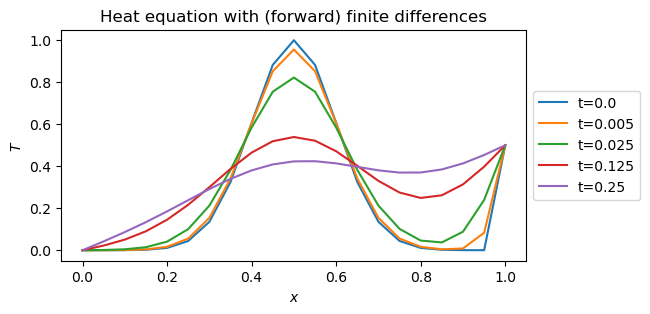

In [34]:
# plot the solution at several times
fig, ax = plt.subplots(figsize=(6, 3))

plot_js = [0,2,10,50,100] # select a few times to plot
for j in plot_js:
    ax.plot(xi, uu_crank[j], label='t='+str(tj[j]))

ax.set_xlabel('$x$')
ax.set_ylabel('$T$')
ax.set_title('Heat equation with (forward) finite differences')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5));    

#### Combine code into functions


In [38]:
def crank_nicolson(N):
    tj = linspace(t0,T,N+1) # time points
    k = (T-t0)/N # timestep size

    sigma = k*D/h**2
    A = (1-2*sigma)*eye(n-1) + diag(sigma*ones(n-2),-1) + diag(sigma*ones(n-2),1)
    A_hat = (1+2*sigma)*eye(n-1) - diag(sigma*ones(n-2),-1) - diag(sigma*ones(n-2),1)
    I = eye(len(A))

    A = csr_matrix(A)
    A_hat = csr_matrix(A_hat)
    I = csr_matrix(I)

    # set initital condition
    uu = np.empty((N+1, n+1))
    uu[0] = u0.copy()

    # set left/right boundary conditions
    uu[:,0] = l(tj)
    uu[:,-1] = r(tj)

    # fill in time steps for internal positions
    for j in range(N):
        s = get_s(tj[j])
        s_hat = get_s(tj[j+1])
        uu[j+1,1:-1] = spsolve(I+A_hat, (I+A)@ uu[j,1:-1] + sigma*(s+s_hat) )
        
    return tj,uu,sigma

In [43]:
# plot the solution at several times
def make_fig(xi,uu,ts):
    fig, ax = plt.subplots(figsize=(6, 3))

    for j,t in enumerate(ts):
        ax.plot(xi,uu[j], label='t='+str(ts[j]))

    ax.set_xlabel('position $x$')
    ax.set_ylabel('$u(x,t)$')
    return fig, ax

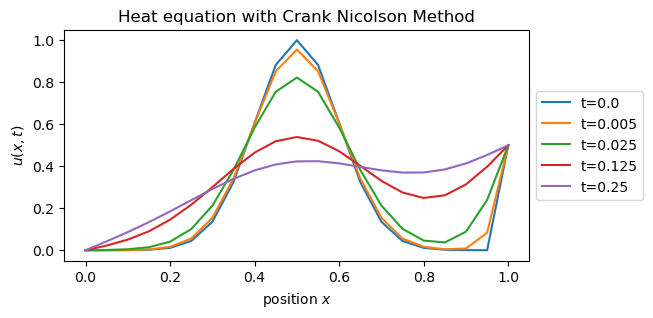

In [46]:
# implement Crank-Nocolson method with specified # of time steps, N
tj,uu_crank,sigma = crank_nicolson(N)

# select times to plot lines for
plot_js = [0,2,10,50,100] # select a few times to plot
ts = tj[plot_js]

# plot solution at those times
fig,ax = make_fig(xi,uu_crank[plot_js],ts)
ax.set_title('Heat equation with Crank Nicolson Method')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5));    